**Import** **Libraries**

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

**Load** **Dataset**

In [12]:
# Verify the path to your dataset. If the file is in a different location,
# please update the path below accordingly.
df = pd.read_csv("/content/drive/MyDrive/Dataset/Copy of Salary Data.csv")
print(df.head())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


**Convert text data into numbers**

In [13]:
le_gender = LabelEncoder()
le_education = LabelEncoder()
le_job = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])
df['Education Level'] = le_education.fit_transform(df['Education Level'])
df['Job Title'] = le_job.fit_transform(df['Job Title'])

S**elect input and output**

In [17]:
X = df[['Age', 'Gender', 'Education Level',
        'Job Title', 'Years of Experience']]

**Target variable(y)**

In [18]:
y = df['Salary']

**Create Linear Regression Model**

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

model = LinearRegression()

# Split data into training and testing sets to ensure X_train and y_train are defined
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Drop rows with NaN values from X_train and y_train
# This ensures that the model only trains on complete data.
# We find the indices of rows in X_train that do not contain any NaN values
valid_indices = X_train.dropna().index
X_train_cleaned = X_train.loc[valid_indices]
y_train_cleaned = y_train.loc[valid_indices]

model.fit(X_train_cleaned, y_train_cleaned)

LinearRegression()

**Predict Salary**

In [21]:
# Drop rows with NaN values from X_test.
# We find the indices of rows in X_test that do not contain any NaN values
valid_indices_test = X_test.dropna().index
X_test_cleaned = X_test.loc[valid_indices_test]

y_pred = model.predict(X_test_cleaned)

print(y_pred)

[175096.25875917  93504.47593219 131538.73660479  83895.6176723
 161395.2566041  187312.80103305 157786.0475545  104594.74256864
  57494.47925243 100930.67845064 142368.67532088 160222.53599321
  51192.24034365  89338.6504642   63239.20362351 162571.42587556
  69027.85826747  48238.38940689  79402.27793422  98313.82138892
 130213.67039897 107996.86218501 165354.89075818  61240.76232157
  88057.01356788  48694.6117089  178027.98490675 157011.57508933
 147381.13711097  43352.21981352 126034.56361685  54830.48177074
 152663.45005367  91020.12861157  16954.38213944 183856.46201769
  50993.12800875  37669.03279441  58942.48499568  44245.52401021
  88368.51432469 168598.91151395 164444.43641542  42997.02775779
 156460.98134868 123227.52875449  53243.30747876  49045.93493269
  35293.68455175 103039.65261926  80531.70394164  77284.36923135
 103922.82587182 163069.15480907  65863.37863822 188031.85768935
  77305.68696041  46888.20376283  85992.20864611 119120.59077137
 139358.65883119 159662.53

**Check Accuracy**

In [22]:
y_test_cleaned = y_test.loc[valid_indices_test]
print("R2 Score:", r2_score(y_test_cleaned, y_pred))
print("MAE:", mean_absolute_error(y_test_cleaned, y_pred))

R2 Score: 0.8981220940200827
MAE: 10804.241259796765


**Data Visualization**

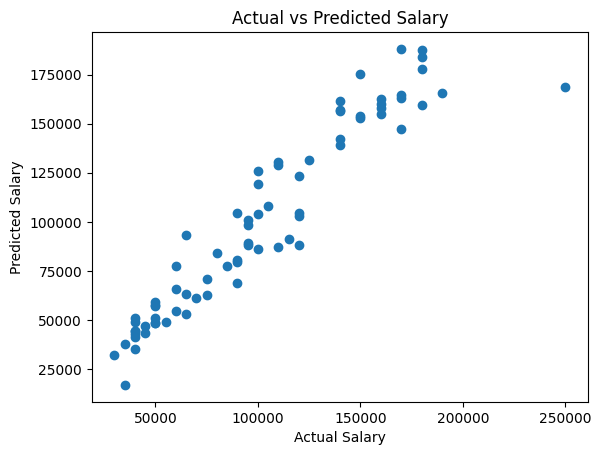

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test_cleaned, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               375 non-null    int64  
 2   Education Level      375 non-null    int64  
 3   Job Title            375 non-null    int64  
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.7 KB


**Check missing value**

In [25]:
print(df.isnull().sum())

Age                    2
Gender                 0
Education Level        0
Job Title              0
Years of Experience    2
Salary                 2
dtype: int64


**Fill missing value**

In [26]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Years of Experience'].fillna(df['Years of Experience'].mean(), inplace=True)
df['Salary'].fillna(df['Salary'].mean(), inplace=True)

/tmp/ipykernel_1231/1443015403.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_1231/1443015403.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [27]:
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


**Define X and Y**

In [28]:
X = df[['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience']]
y = df['Salary']

**Split data**

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Model**

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

**Predict**

In [31]:
pred = model.predict(X_test)
print(pred[:5])

[157500.  69400. 127700.  99100. 152850.]


**Check Accuracy**

In [32]:
from sklearn.metrics import r2_score

score = r2_score(y_test, pred)
print("R2 Score:", score)

R2 Score: 0.9274858791460896


In [33]:
import numpy as np

# User Input

age = float(input("Enter Age: "))
gender = int(input("Enter Gender (0=Female, 1=Male): "))

# For 'Education Level', input the string and then transform it using the LabelEncoder.
# Ensure the entered education level was seen during model training.
education_str = input("Enter Education Level (e.g., Bachelor's, Master's, PhD): ")
education = le_education.transform([education_str])[0]

# For 'Job Title', input the string and then transform it using the LabelEncoder.
# Ensure the entered job title was seen during model training.
job_str = input("Enter Job Title (e.g., Software Engineer, Data Analyst): ")
job = le_job.transform([job_str])[0]

experience = float(input("Enter Years of Experience: "))

# Prediction
salary = model.predict(np.array([[age, gender, education, job, experience]]))

print("Predicted Salary: ", round(salary[0], 2))


Enter Age: 36
Enter Gender (0=Female, 1=Male): 0
Enter Education Level (e.g., Bachelor's, Master's, PhD): Bachelor's
Enter Job Title (e.g., Software Engineer, Data Analyst): Data Analyst
Enter Years of Experience: 8
Predicted Salary:  58450.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
